# Credit Card Fraud Detection
This notebook compares several supervised classification algorithms on the Credit Card Fraud Detection dataset to demonstrate how different data mining algorithms perform on a heavily imbalanced dataset.

In [10]:
!pip install pandas
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib
!pip install numpy
!pip install imbalanced-learn
!pip install xgboost


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 3.7 MB/s eta 0:00:13
   - -------------------------------------- 1.6/48.9 MB 3.6 MB/s eta 0:00:14
   - -------------------------------------- 2.4/48.9 MB 3.5 MB/s eta 0:00:14
   -- ------------------------------------- 3.1/48.9 MB 3.6 MB/s eta 0:00:13
   --- ---------

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
except ImportError:
    print("Please install imbalanced-learn: !pip install imbalanced-learn")

try:
    from xgboost import XGBClassifier
    has_xgboost = True
except ImportError:
    print("XGBoost not found. (!pip install xgboost)")
    has_xgboost = False

%matplotlib inline

## 1. Load Data
The dataset is expected to be located at `dataset/creditcard.csv`.

In [12]:
filepath = 'dataset/creditcard.csv'
if not os.path.exists(filepath):
    print(f"Error: Dataset not found at {filepath}")
else:
    df = pd.read_csv(filepath)
    print("Data loaded successfully. Shape:", df.shape)
    display(df.head())

Data loaded successfully. Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis (EDA)
We visualize the extreme class imbalance, the distribution of features for each class, and the feature correlations.

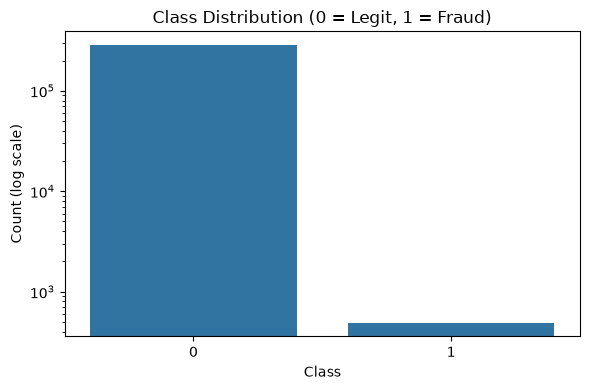

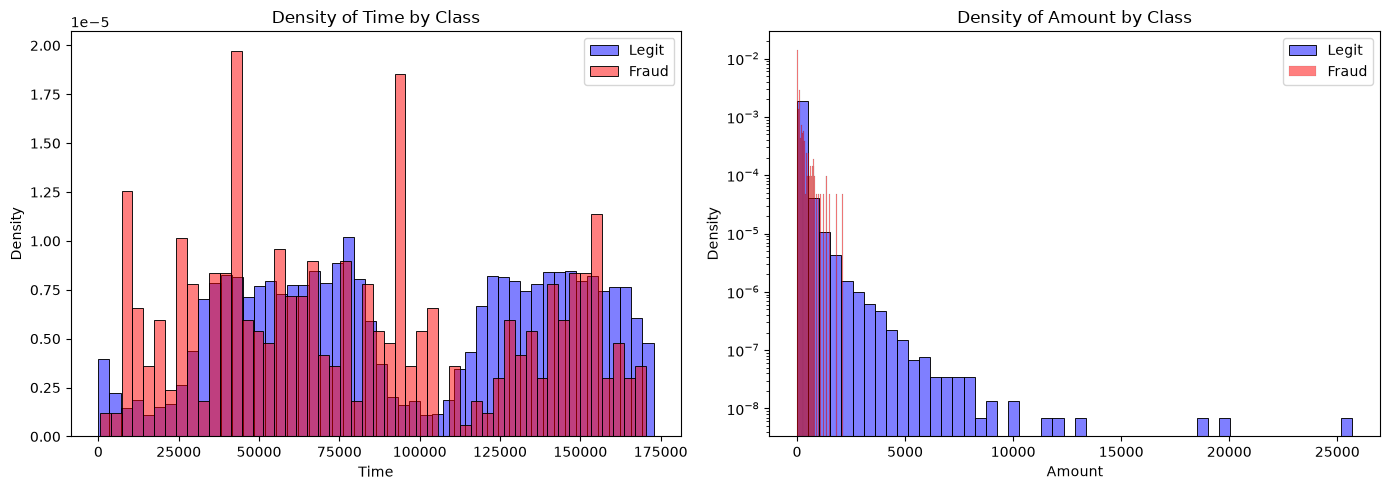

Generating correlation heatmap (this may take a moment)...


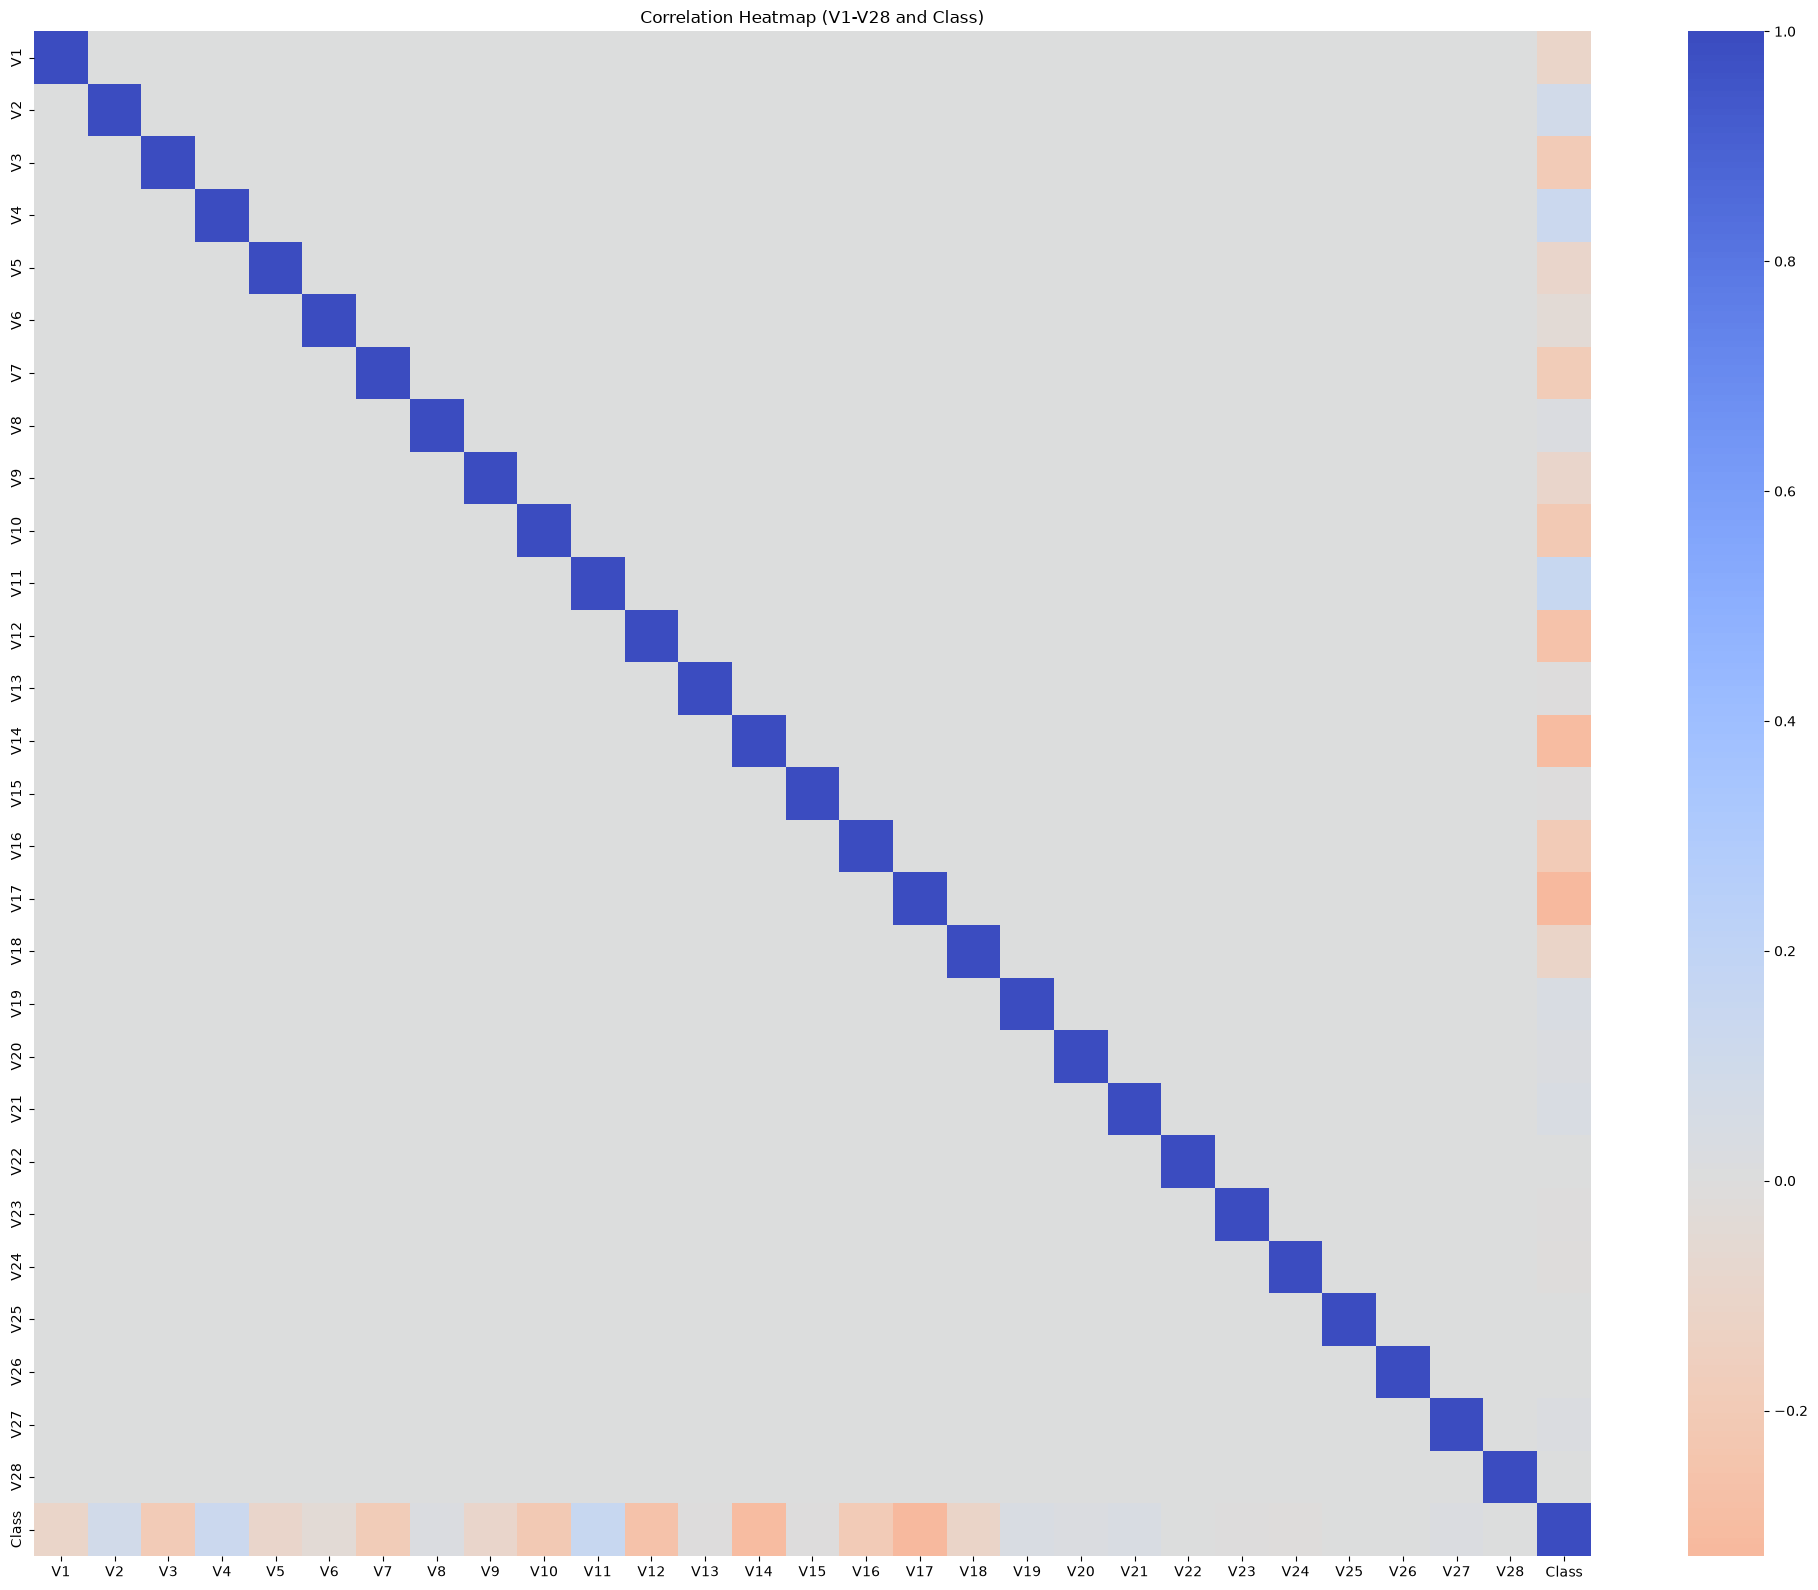

In [13]:
# 1. Class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class')
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.yscale('log')
plt.ylabel('Count (log scale)')
plt.tight_layout()
plt.show()

# 2. Distribution of Amount and Time split by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, color='blue', alpha=0.5, label='Legit', ax=axes[0], stat='density')
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, color='red', alpha=0.5, label='Fraud', ax=axes[0], stat='density')
axes[0].set_title('Density of Time by Class')
axes[0].legend()

sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', alpha=0.5, label='Legit', ax=axes[1], stat='density')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.5, label='Fraud', ax=axes[1], stat='density')
axes[1].set_title('Density of Amount by Class')
axes[1].set_yscale('log')
axes[1].legend()
plt.tight_layout()
plt.show()

# 3. Correlation heatmap across V1-V28
print("Generating correlation heatmap (this may take a moment)...")
plt.figure(figsize=(20, 16))
v_features = [f'V{i}' for i in range(1, 29)] + ['Class']
corr = df[v_features].corr()
sns.heatmap(corr, cmap='coolwarm_r', center=0, annot=False)
plt.title('Correlation Heatmap (V1-V28 and Class)')
plt.tight_layout()
plt.show()

## 3. Preprocessing
We scale the `Amount` and `Time` features and split the dataset 80/20 using stratification.

In [14]:
# Scale Amount and Time (V features are already PCA-scaled)
scaler = StandardScaler()
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# Train/test split with stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (227845, 30)
Test set shape: (56962, 30)


## 4. Compare Imbalance Strategies
We use Logistic Regression to demonstrate why standard models fail on imbalanced data and why strategies like SMOTE, Undersampling, or Class Weights are necessary.

In [15]:
print("--- Comparing Imbalance Strategies using Logistic Regression ---")

strategies = {
    'Baseline (No Resampling)': (X_train, y_train, LogisticRegression(max_iter=1000, random_state=42)),
    'Class Weight Balanced': (X_train, y_train, LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    'Random Undersampling': (*RandomUnderSampler(random_state=42).fit_resample(X_train, y_train), LogisticRegression(max_iter=1000, random_state=42)),
    'SMOTE': (*SMOTE(random_state=42).fit_resample(X_train, y_train), LogisticRegression(max_iter=1000, random_state=42))
}

strategy_results = []

for name, (X_tr, y_tr, model) in strategies.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    strategy_results.append({
        'Strategy': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
df_strategies = pd.DataFrame(strategy_results)
display(df_strategies)

--- Comparing Imbalance Strategies using Logistic Regression ---


,Strategy,Accuracy,Precision,Recall,F1-Score
0,Baseline (No Resampling),0.999157,0.828947,0.642857,0.724138
1,Class Weight Balanced,0.975475,0.060852,0.918367,0.114141
2,Random Undersampling,0.960342,0.038445,0.918367,0.073801
3,SMOTE,0.974264,0.058140,0.918367,0.109356


## 5. Main Algorithm Comparison
We will now train multiple algorithms using **SMOTE** resampled training data to have a fair comparison.

Applying SMOTE...
Training Logistic Regression (This may take a while for KNN/Ensembles)...


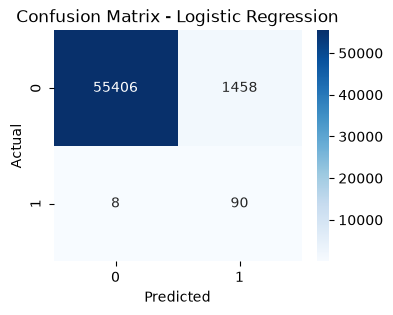

Training Decision Tree (This may take a while for KNN/Ensembles)...


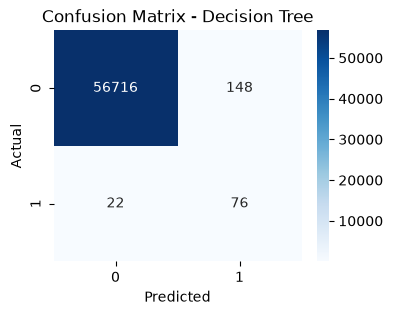

Training Random Forest (This may take a while for KNN/Ensembles)...


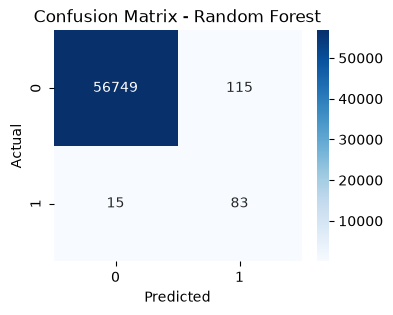

Training Naive Bayes (This may take a while for KNN/Ensembles)...


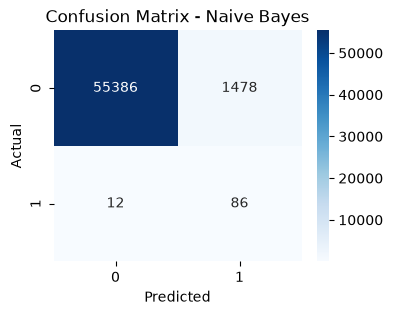

Training K-Nearest Neighbors (This may take a while for KNN/Ensembles)...


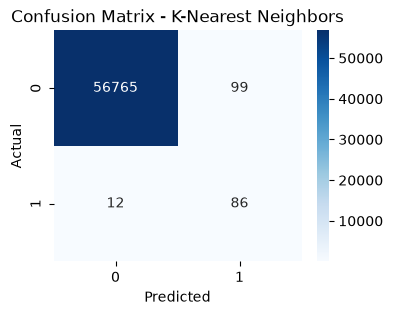

Training XGBoost (This may take a while for KNN/Ensembles)...


c:\AAST MASTER\Data Mining Algorithms\project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:42:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


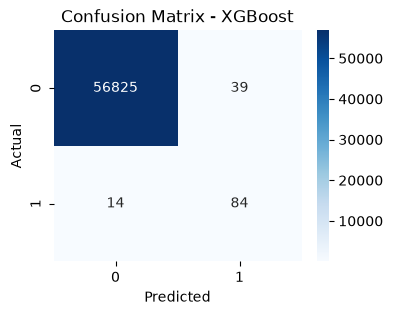

,Algorithm,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.974264,0.058140,0.918367,0.109356,0.969848,0.770341
1,Decision Tree,0.997016,0.339286,0.775510,0.472050,0.886454,0.557591
2,Random Forest,0.997718,0.419192,0.846939,0.560811,0.979999,0.796678
3,Naive Bayes,0.973842,0.054987,0.877551,0.103490,0.964414,0.449686
4,K-Nearest Neighbors,0.998051,0.464865,0.877551,0.607774,0.953588,0.771988
5,XGBoost,0.999070,0.682927,0.857143,0.760181,0.974523,0.866038


In [16]:
print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=10),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_jobs=-1) 
}

if has_xgboost:
    models['XGBoost'] = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    
results = []
roc_curves = {}
pr_curves = {}

for name, model in models.items():
    print(f"Training {name} (This may take a while for KNN/Ensembles)...")
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    roc_curves[name] = (fpr, tpr, roc_auc)
    pr_curves[name] = (precision_vals, recall_vals, pr_auc)
    
    results.append({
        'Algorithm': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

df_results = pd.DataFrame(results)
display(df_results)

## 6. Plot Final Results
Comparing the algorithms visually using a bar chart (Accuracy vs Recall vs F1), ROC curves, and PR curves.

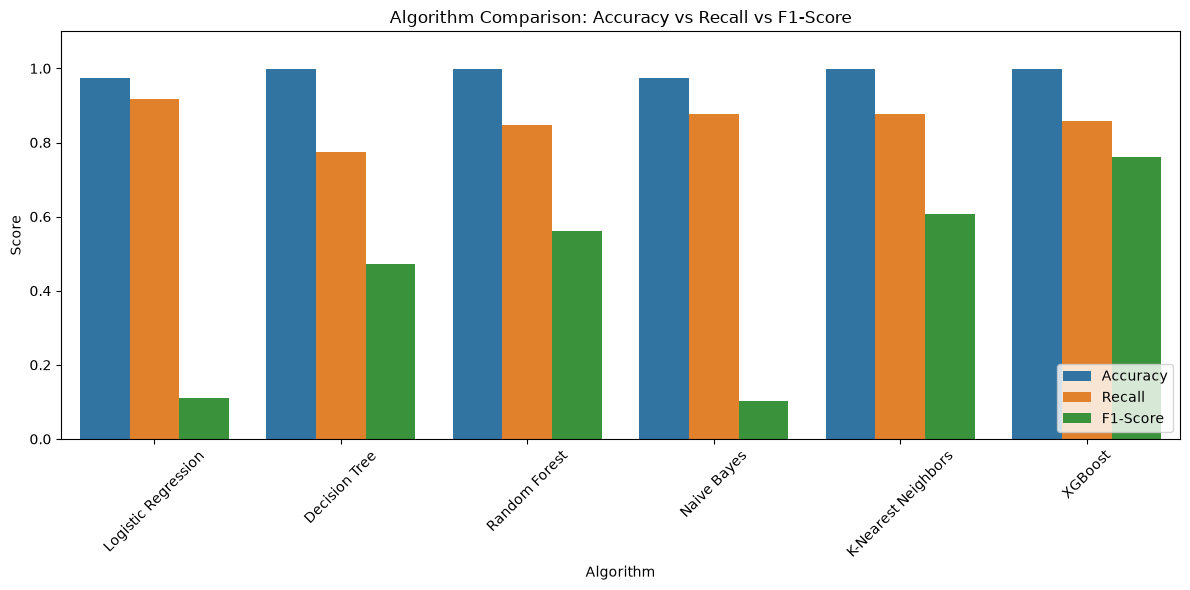

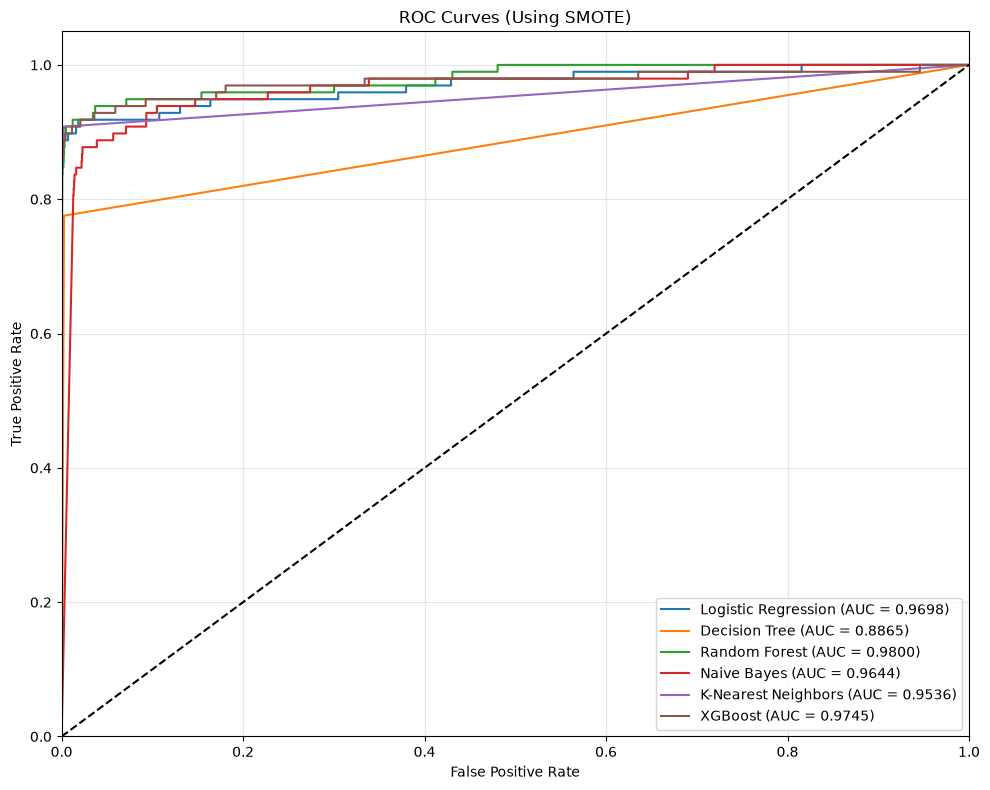

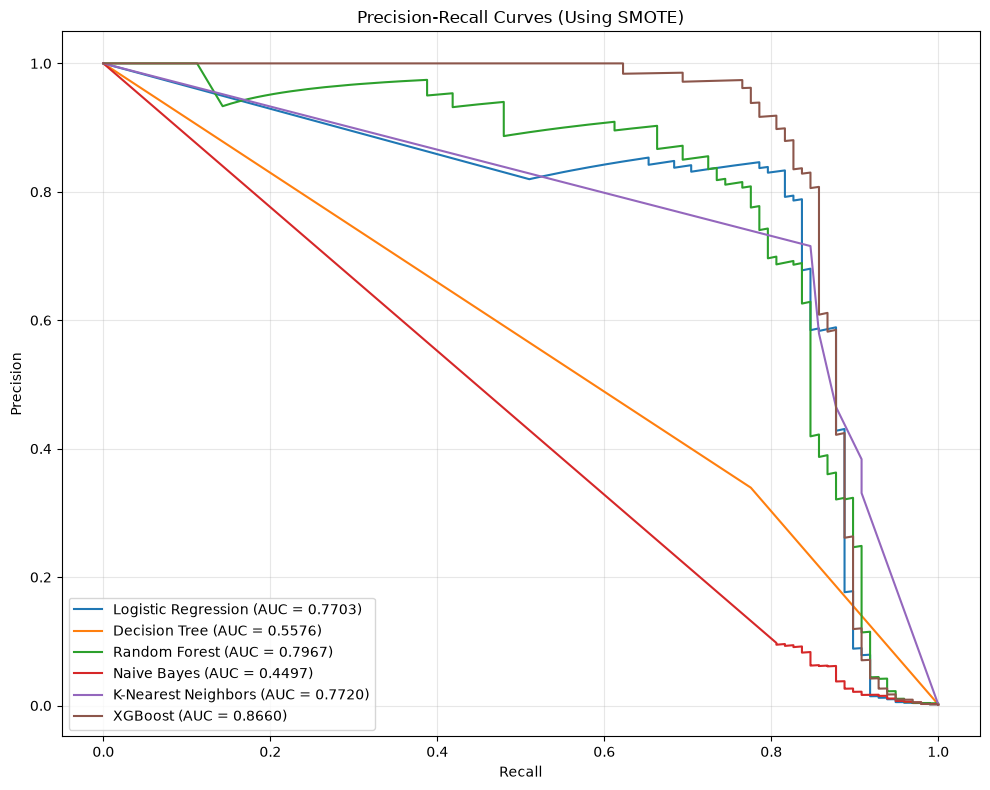

In [17]:
# Bar chart comparing accuracy vs F1/recall
df_melted = df_results.melt(id_vars='Algorithm', value_vars=['Accuracy', 'Recall', 'F1-Score'], 
                            var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Algorithm', y='Score', hue='Metric')
plt.title('Algorithm Comparison: Accuracy vs Recall vs F1-Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Using SMOTE)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PR Curves
plt.figure(figsize=(10, 8))
for name, (prec, rec, pr_auc) in pr_curves.items():
    plt.plot(rec, prec, label=f'{name} (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Using SMOTE)')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Conclusion

Because the dataset is heavily imbalanced (~0.17% fraud), **accuracy is a highly misleading metric**. A model that predicts "Legit" for every transaction will achieve ~99.83% accuracy but will have a 0% recall, missing all fraudulent transactions. 

In our evaluation, we observed that while all models achieved very high accuracy (often > 90%), their performance on **Recall and F1-score varied significantly**. Recall is the critical metric here because missing a fraudulent transaction is much more costly than a false alarm. The side-by-side bar chart clearly proves that accuracy alone masks the true effectiveness of the algorithms.

### Trade-offs
1. **Ensembles (Random Forest, XGBoost):** These typically yield the best balance of Precision and Recall (highest PR-AUC) and are less likely to over-predict fraud compared to simpler models trained on SMOTE data. However, they lack the immediate interpretability of simpler models and are computationally more expensive to train.
2. **Logistic Regression:** Extremely fast and interpretable. With SMOTE or Class Weights, it often achieves very high Recall, but at the cost of many False Positives (low precision).
3. **Decision Tree:** Provides a simple, rule-based approach that is easy to explain but is very prone to overfitting.
4. **K-Nearest Neighbors & Naive Bayes:** Distance-based and probabilistic approaches can struggle with the highly correlated PCA features and the synthetic points generated by SMOTE in high-dimensional spaces, resulting in sub-optimal PR-AUC and long inference times (for KNN).

### Imbalance Handling Importance
Our strategy comparison shows that the choice of imbalance handling (SMOTE vs. Random Undersampling vs. Class Weights) drastically changes the model's behavior. Relying on no resampling completely fails to detect fraud effectively, while SMOTE and Class Weights offer robust improvements to Recall.